# 01a - Polinomio de Taylor
---

# Importamos librerías

In [1]:
import numpy as np #para manejar arreglos
from matplotlib import pyplot as plt #para graficar
import math #contiene el factorial

plt.rcParams["figure.figsize"] = (10,7) #tamaño de los gráficos: ancho x alto

# Calcular un polinomio de Taylor y graficarlo junto con la función

## Objetivo: graficar $f(x)=\text{e}^x$ y sus polinomios de Taylor en un mismo gráfico, con $x_0 = 0$, para $x$ entre -2 y 2, y para órdenes 1, 2 y 3.

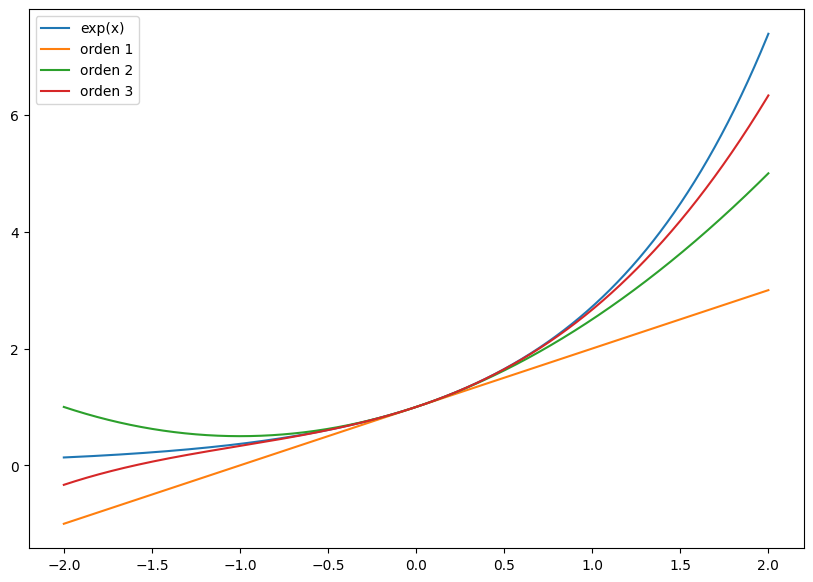

In [3]:
# math.factorial(3) #factorial

def func(x):
  y = np.exp(x)
  return y

# defino pols de taylor
def pol_taylor1(x,a):
    y = np.exp(a) + np.exp(a)*(x-a)
    return y

#COMPLETAR: definir pols Taylor orden 2 y 3.
def pol_taylor2(x,a):
    y = pol_taylor1(x,a) + 0.5*np.exp(a)*(x-a)**2
    return y

def pol_taylor3(x,a):
    y = pol_taylor2(x,a) + (1/math.factorial(3))*np.exp(a)*(x-a)**3
    return y

# defino vectores de X y de Y para graficar
valores_x = np.linspace(-2,2,10000)

valores_y = func(valores_x)
valores_taylor1 = pol_taylor1(valores_x, 0)

# COMPLETAR: crear valores de Y para pols Taylor orden 2 y 3
valores_taylor2 = pol_taylor2(valores_x, 0)
valores_taylor3 = pol_taylor3(valores_x, 0)

# grafico
plt.plot(valores_x, valores_y, label="exp(x)")
plt.plot(valores_x, valores_taylor1, label="orden 1")

# COMPLETAR graficar pols Taylor orden 2 y 3.
plt.plot(valores_x, valores_taylor2, label="orden 2")
plt.plot(valores_x, valores_taylor3, label="orden 3")

plt.legend()
# plt.ylim(-0.5,2)

# Chequear errores

## Objetivo: usar los polinomios de Taylor anteriores para aproximar $\text{e}^{0.1}$. Para cada órden inspeccionar el error que se está cometiendo.

In [4]:
# la comida va aquí..
b = 0.1
valor_posta = np.exp(b)
print("Valor dado por Python:", valor_posta) # valor posta
print("Aproximación a orden 1:", pol_taylor1(b,0)) #aprox a orden 1
print("Aproximación a orden 2:", pol_taylor2(b,0))
print("Aproximación a orden 3:", pol_taylor3(b,0))
print("")
print("Error a órden 1:", abs(valor_posta-pol_taylor1(b,0)))

# COMPLETAR: imprimir las aproximaciones a órdenes 2 y 3. ¿Qué observa?
print("Error a orden 2:", abs(valor_posta-pol_taylor2(b,0)))
print("Error a orden 3:", abs(valor_posta-pol_taylor3(b,0)))

Valor dado por Python: 1.1051709180756477
Aproximación a orden 1: 1.1
Aproximación a orden 2: 1.105
Aproximación a orden 3: 1.1051666666666666

Error a órden 1: 0.005170918075647624
Error a órden 2: 0.0001709180756477302
Error a órden 3: 4.2514089810818945e-06


# Averiguar el orden para que el error sea menor a uno deseado

## Objetivo: acotar el resto de Taylor para $f(x)=\text{e}^x$ con $x_0 = 0$, y encontrar el órden (el $n$) para asegurar que el error cometido al aproximar $\text{e}^{0.1}$ sea menor a $10^{-8}$.

In [5]:
# primero hacer a mano. Recordar que el objetivo es aproximar exp(0.1)

# Ya acoté a mano el resto de Taylor... ahora hago lo que sigue


# definir una función que calcular la cota del error de Taylor dado un órden
def cota_error(n):
  resultado = 3*(0.1)**(n+1)/math.factorial(n+1) #esto es la cota del error que hice a mano antes
  return resultado

# con un while aumentar el órden hasta que el error sera menor o igual al deseado
n = 0
while cota_error(n) >= 10**(-8):
  n = n + 1

print("El órden encontrado para que el error sea menor al deseado es:", n)
print("Chequeamos la cota del error para ese valor de n encontrado:", cota_error(n))

El órden encontrado para que el error sea menor al deseado es: 5
Chequeamos la cota del error para ese valor de n encontrado: 4.1666666666666676e-09


# Ejercicio
- ## Graficar $f(x)=\ln(x)$ para $x$ entre 0.1 y 2.
- ## Graficar los pols. de Taylor de órdenes 1, 2 y 3 con $x_0=1$ junto a la función.
- ## Aproximar $\ln(1.1)$ y ver el error que se está cometiendo para cada órden.
- ## Acotar el resto de Taylor y encontrar el órden para asegurar que el error sea menor a $10^{-10}$

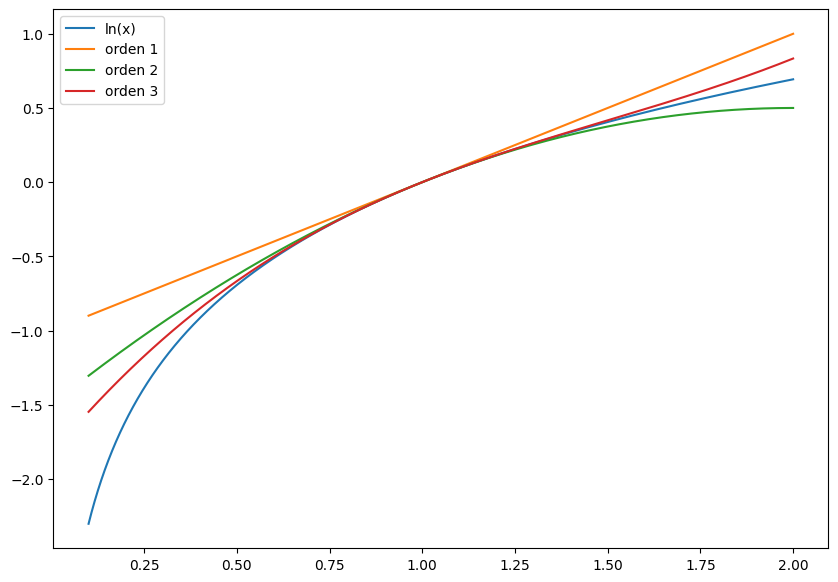

In [11]:
# np.log(x) # es el logaritmo natural
def func(x):
  y = np.log(x)
  return y

# defino pols de Taylor
def pol_taylor1(x,a):
    y = np.log(a) + (1/a)*(x-a)
    return y

#COMPLETAR: definir pols Taylor orden 2 y 3.
def pol_taylor2(x,a):
    y = pol_taylor1(x,a) + 0.5*(-1/a**2)*(x-a)**2
    return y

def pol_taylor3(x,a):
    y = pol_taylor2(x,a) + (1/math.factorial(3))*(2/a**3)*(x-a)**3
    return y

# defino vectores de X y de Y para graficar
valores_x = np.linspace(0.1,2,10000)

valores_y = func(valores_x)
valores_taylor1 = pol_taylor1(valores_x, 1)

# COMPLETAR: crear valores de Y para pols Taylor orden 2 y 3
valores_taylor2 = pol_taylor2(valores_x, 1)
valores_taylor3 = pol_taylor3(valores_x, 1)

# grafico
plt.plot(valores_x, valores_y, label="ln(x)")
plt.plot(valores_x, valores_taylor1, label="orden 1")

# COMPLETAR graficar pols taylor orden 2 y 3.
plt.plot(valores_x, valores_taylor2, label="orden 2")
plt.plot(valores_x, valores_taylor3, label="orden 3")

plt.legend()
# plt.ylim(-0.5,2)

In [12]:
# aproximaciones y errores para cada orden
b = 1.1
a = 1
valor_posta = np.log(b)
print("Valor dado por Python:", valor_posta) # valor posta
print("Aproximación a orden 1:", pol_taylor1(b,a)) #aprox a orden 1
print("Aproximación a orden 2:", pol_taylor2(b,a))
print("Aproximación a orden 3:", pol_taylor3(b,a))
print("")

print("Error a órden 1:", abs(valor_posta-pol_taylor1(b,a)))
print("Error a orden 2:", abs(valor_posta-pol_taylor2(b,a)))
print("Error a orden 3:", abs(valor_posta-pol_taylor3(b,a)))

Valor dado por Python: 0.09531017980432493
Aproximación a orden 1: 0.10000000000000009
Aproximación a orden 2: 0.09500000000000008
Aproximación a orden 3: 0.09533333333333342

Error a órden 1: 0.004689820195675154
Error a orden 2: 0.0003101798043248505
Error a orden 3: 2.3153529008487772e-05


In [13]:
# encontrar el orden para que el error sea menor al deseado


# primero acoto el resto de Taylor y que me quede solamente dependiendo del n... ahora hago en Python lo que sigue


def cota_error(n):
  resultado = (0.1)**(n+1)/(n+1) #esto es la cota del error que hice a mano antes
  return resultado

# con un while aumentar el órden hasta que el error sera menor o igual al deseado
n = 0
while cota_error(n) >= 10**(-10):
  n = n + 1

print("El órden encontrado para que el error sea menor al deseado es:", n)
print("Chequeamos la cota del error para ese valor de n encontrado:", cota_error(n))

El órden encontrado para que el error sea menor al deseado es: 9
Chequeamos la cota del error para ese valor de n encontrado: 1.0000000000000006e-11


# Ejercicios 4, 6 y 8 de la P1.